# Compare two runs: Adaptive (HS) vs Adaptive (Covariance)

Provide **two paths** to `timeseries.csv` (one HS, one Covar).  
Optionally provide an **exact** `timeseries.csv` (or an exact column inside the CSV).


In [39]:
import numpy as np
import qutip as qt

# -----------------------------
# Geometry: N x N square lattice
# -----------------------------
def site_id(x: int, y: int, N: int) -> int:
    return x + N * y

def build_positions_square_lattice(N: int, a: float = 1.0, z0: float = 0.0) -> np.ndarray:
    L = N * N
    pos = np.zeros((L, 3), dtype=float)
    for y in range(N):
        for x in range(N):
            i = site_id(x, y, N)
            pos[i] = np.array([a * x, a * y, z0], dtype=float)
    return pos

# -----------------------------
# Dipolar couplings
# J_{αβ}(r) = D / r^3 * (δ_{αβ} - 3 rhat_α rhat_β)
# -----------------------------
def dipolar_tensor(r_ij: np.ndarray, D: float = 1.0, r_min: float = 1e-12) -> np.ndarray:
    r = float(np.linalg.norm(r_ij))
    if r < r_min:
        return np.zeros((3, 3), dtype=float)
    rhat = r_ij / r
    pref = D / (r**3)
    return pref * (np.eye(3) - 3.0 * np.outer(rhat, rhat))

# -----------------------------
# Build local Pauli operators as sparse Qobj
# -----------------------------
def local_paulis(L: int):
    sx, sy, sz = [], [], []
    for i in range(L):
        ops = [qt.qeye(2)] * L

        ops[i] = qt.sigmax()
        sx.append(qt.tensor(ops))

        ops[i] = qt.sigmay()
        sy.append(qt.tensor(ops))

        ops[i] = qt.sigmaz()
        sz.append(qt.tensor(ops))
    return sx, sy, sz

# -----------------------------
# Build full Hamiltonian
# -----------------------------
def build_dipolar_XYZ_H(N: int, a: float = 1.0, D: float = 1.0, include_offdiag: bool = False):
    L = N * N
    pos = build_positions_square_lattice(N, a=a, z0=0.0)

    sx, sy, sz = local_paulis(L)
    H = 0 * sx[0]  # zero operator with correct dims

    for i in range(L):
        for j in range(i + 1, L):
            J = dipolar_tensor(pos[i] - pos[j], D=D)

            # "XYZ-only" diagonal couplings
            H += J[0, 0] * sx[i] * sx[j]
            H += J[1, 1] * sy[i] * sy[j]
            H += J[2, 2] * sz[i] * sz[j]

            if include_offdiag:
                # full dipolar tensor (often omitted)
                H += J[0, 1] * sx[i] * sy[j] + J[1, 0] * sy[i] * sx[j]
                H += J[0, 2] * sx[i] * sz[j] + J[2, 0] * sz[i] * sx[j]
                H += J[1, 2] * sy[i] * sz[j] + J[2, 1] * sz[i] * sy[j]

    return H

# -----------------------------
# Example simulation
# -----------------------------
N = 4               # 4x4 => 16 spins
a = 10.0
D = 1.0             # tune
include_offdiag = False  # set True if you want full tensor terms

H = build_dipolar_XYZ_H(N=N, a=a, D=D, include_offdiag=include_offdiag)

L = N * N

# Initial product state |0...0> (sigma_z eigen +1). Change as you like.
psi0 = qt.tensor([qt.basis(2, 0)] * L)

# Time grid
tlist = np.linspace(0.0, 10., 100)  

# Observable: <Sz> at site 0
Sz0 = qt.tensor([qt.sigmaz()] + [qt.qeye(2)] * (L - 1))

# Unitary evolution
result = qt.sesolve(H, psi0, tlist, e_ops=[Sz0])

exp_Sz0 = result.expect[0]
print(exp_Sz0)


[1.         0.99999963 0.9999985  0.99999663 0.999994   0.99999063
 0.9999865  0.99998163 0.99997601 0.99996964 0.99996251 0.99995464
 0.99994602 0.99993665 0.99992653 0.99991566 0.99990404 0.99989167
 0.99987855 0.99986468 0.99985006 0.9998347  0.99981858 0.99980171
 0.9997841  0.99976573 0.99974662 0.99972676 0.99970615 0.99968478
 0.99966267 0.99963982 0.99961621 0.99959185 0.99956674 0.99954089
 0.99951429 0.99948694 0.99945884 0.99942999 0.99940039 0.99937004
 0.99933895 0.99930711 0.99927452 0.99924118 0.99920709 0.99917226
 0.99913668 0.99910035 0.99906327 0.99902544 0.99898687 0.99894755
 0.99890748 0.99886667 0.99882511 0.9987828  0.99873974 0.99869594
 0.99865139 0.99860609 0.99856005 0.99851326 0.99846573 0.99841744
 0.99836842 0.99831864 0.99826812 0.99821686 0.99816485 0.99811209
 0.99805859 0.99800434 0.99794935 0.99789361 0.99783713 0.9977799
 0.99772193 0.99766321 0.99760375 0.99754355 0.9974826  0.99742091
 0.99735847 0.99729529 0.99723137 0.9971667  0.99710129 0.99703

In [40]:
# --- Inputs: set your two paths here ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

folder_path_ = "/home/tomas/phoenix/data/"
_file_path = "/timeseries.csv"
# Required
path_hs    = Path(
            folder_path_ +
    "20260208_211920__dip__N4__ell5__m3__eps1e-10__ptail2__dt1.000e-01__tmax10__seedZ0__sigma_HS"   
            + _file_path
            ).expanduser()
path_covar = Path(
            folder_path_ +
            "20260208_212053__dip__N4__ell5__m3__eps1e-10__ptail2__dt1.000e-01__tmax10__seedZ0__sigmaglobal_Z"+
    _file_path
            ).expanduser()

#"20260205_152652__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigmaZ-global" 
#"20260205_152526__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigma_HS" 
                        
# If you want to force a specific observable column name, set it here. Otherwise it's auto-detected.
observable_col_preference = None

# Plot
PLOT_DPI = 140


In [41]:
# --- Helpers ---
def detect_time_col(df: pd.DataFrame) -> str:
    for cand in ["t","time"]:
        if cand in df.columns:
            return cand
    # fallback: first numeric col
    nums = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not nums:
        raise ValueError("No numeric columns found (cannot detect time column).")
    return nums[0]

def detect_observable_col(df: pd.DataFrame, preferred: str | None = None) -> str:
    if preferred is not None and preferred in df.columns:
        return preferred

    # common names in your runs
    cands = [
        "O_{\ell, m, \epsilon}",
        "O_{\ell,m,\epsilon}",
        "O_lm_eps",
        "obs",
        "ev",
        "value",
    ]
    for c in cands:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            return c

    tcol = detect_time_col(df)
    nums = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != tcol]
    if not nums:
        raise ValueError("No numeric observable column found.")
    return nums[0]

def standardize(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()
    tcol = detect_time_col(df)
    ocol = detect_observable_col(df, observable_col_preference)
    df = df.rename(columns={tcol:"t", ocol:"y"})
    df["t"] = df["t"].astype(float)
    df["y"] = df["y"].astype(float)
    df["label"] = label
    return df.sort_values("t").reset_index(drop=True)

def parse_meta_from_path(p: Path) -> dict:
    # best-effort parse from parent folder name
    name = p.parent.name
    meta = {}
    parts = name.split("__")
    # model often is the first token after timestamp
    if parts and re.match(r"^\d{8}_\d{6}$", parts[0]):
        parts = parts[1:]
    if parts:
        meta["model"] = parts[0]
    for token in parts[1:]:
        m = re.match(r"^(N|ell|m)(\d+)$", token)
        if m:
            meta[m.group(1)] = int(m.group(2))
        m = re.match(r"^eps(.+)$", token)
        if m:
            try:
                meta["eps"] = float(m.group(1))
            except Exception:
                meta["eps"] = m.group(1)
    return meta

def nice_title(meta: dict) -> str:
    model = meta.get("model","?")
    N     = meta.get("N","?")
    ell   = meta.get("ell","?")
    m     = meta.get("m","?")
    eps   = meta.get("eps","?")
    # eps formatting
    if isinstance(eps, float):
        eps_str = f"{eps:g}"
    else:
        eps_str = str(eps)
    return f"{model} (N={N}) | ℓ={ell}, m={m}, ε={eps_str}"


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_165650/2215471689.py:18: SyntaxWarning: invalid escape sequence '\e'
  "O_{\ell, m, \epsilon}",
/tmp/ipykernel_165650/2215471689.py:19: SyntaxWarning: invalid escape sequence '\e'
  "O_{\ell,m,\epsilon}",


In [42]:
# --- Load ---
assert path_hs.exists(), f"HS timeseries.csv not found: {path_hs}"
assert path_covar.exists(), f"Covar timeseries.csv not found: {path_covar}"

df_hs  = standardize(pd.read_csv(path_hs),    "Adaptive (HS)")
df_cov = standardize(pd.read_csv(path_covar), "Adaptive (Covariance)")

# --- Align on common t (deterministic column names) ---
aligned = (
    df_hs[["t","y"]].rename(columns={"y": "y_hs"})
    .merge(df_cov[["t","y"]].rename(columns={"y": "y_cov"}), on="t", how="inner")
)

aligned.head()


,t,y_hs,y_cov
0,0.0,0.500000,0.500000
1,0.1,0.500000,0.500000
2,0.2,0.500000,0.500000
3,0.3,0.500000,0.499999
4,0.4,0.499999,0.499999


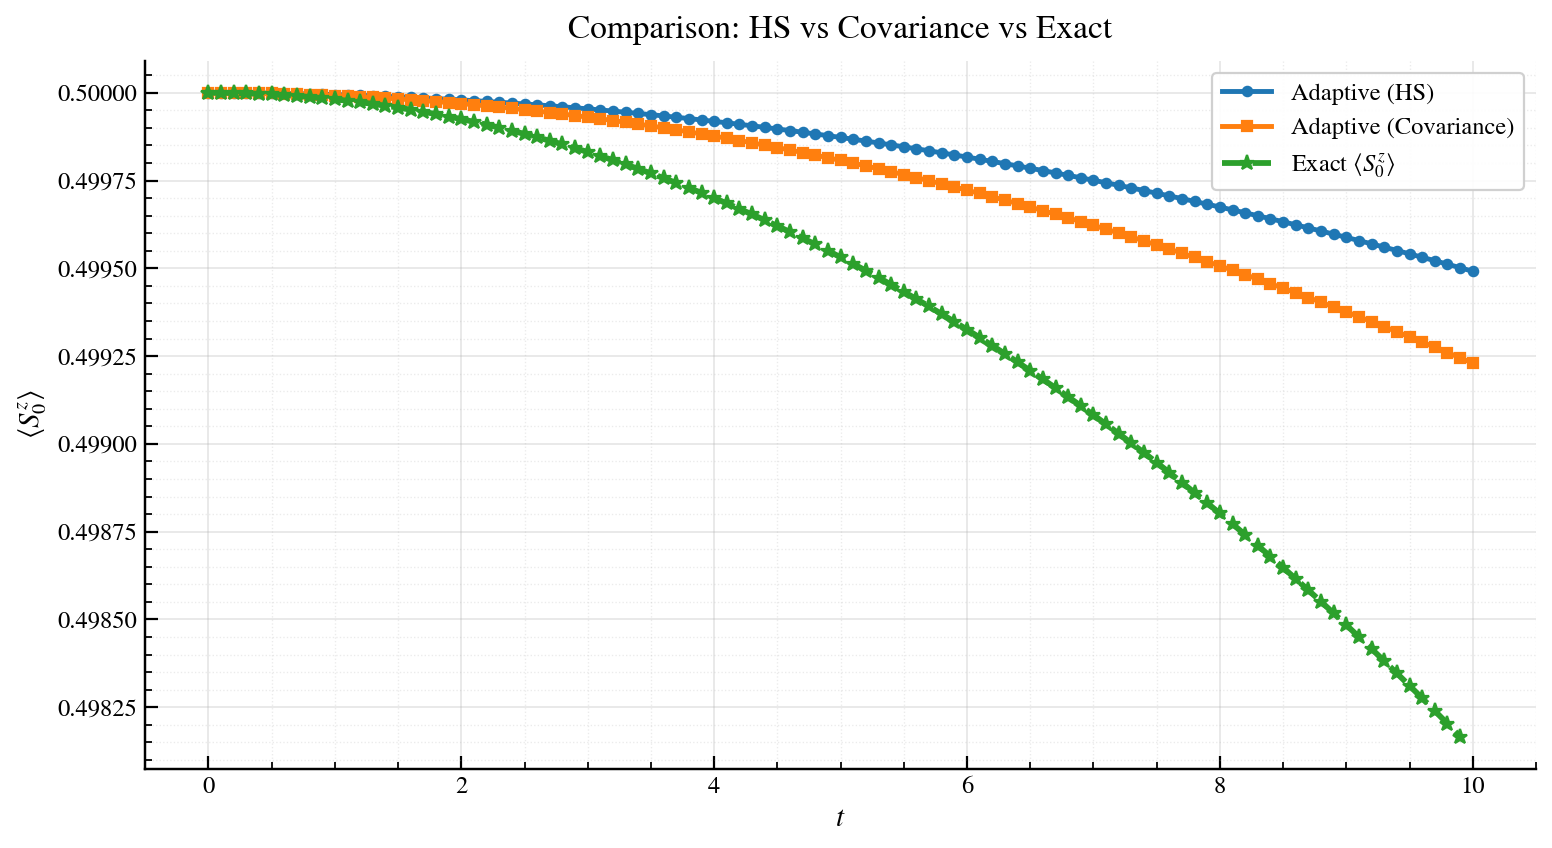

In [43]:
# --- PRETTY + SCIENTIFIC (LaTeX-style), NO DATA CHANGES ---
import matplotlib as mpl
import matplotlib.pyplot as plt

# LaTeX-ish styling (uses mathtext by default; if you *have* LaTeX installed,
# flip usetex=True below)
mpl.rcParams.update({
    "figure.figsize": (9.8, 5.4),
    "figure.dpi": 160,

    # Text / math
    "text.usetex": False,              # set True if you have a LaTeX install
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",

    # Axes
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titlepad": 10,
    "axes.linewidth": 1.1,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # Legend
    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
})

fig, ax = plt.subplots()

# Adaptive HS (same data)
ax.plot(
    aligned["t"],
    aligned["y_hs"],
    marker="o",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (HS)",
)

# Adaptive Covariance (same data)
ax.plot(
    aligned["t"],
    aligned["y_cov"],
    marker="s",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (Covariance)",
)

# Exact (same data + same slicing)
ax.plot(
    aligned["t"][:-1],
    exp_Sz0/2,
    marker="*",
    markersize=7.0,
    linewidth=2.6,
    linestyle="--",
    label=r"Exact $\langle S^z_{0}\rangle$",
)

# Labels / title (LaTeX math)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\langle S^z_{0}\rangle$")
ax.set_title(r"Comparison: HS vs Covariance vs Exact")

# Scientific grid: major + minor
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)

# Clean spines but still “physics plot”
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(loc="best")

plt.tight_layout()
plt.show()


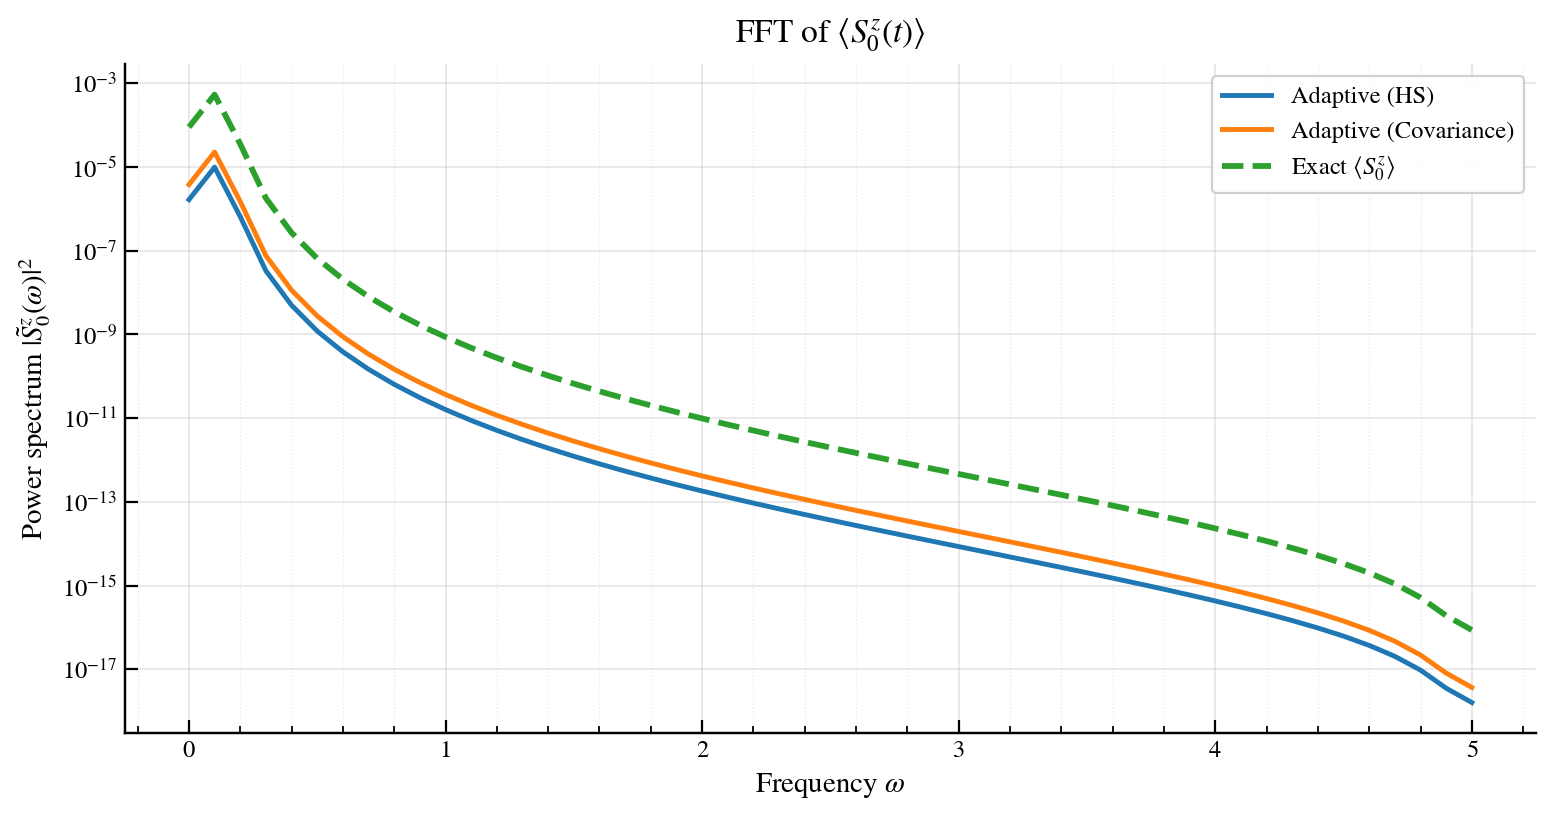

In [44]:
# --- FFT + PLOT (quick, robust) ---
import numpy as np
import matplotlib.pyplot as plt

# Time step from the truncated grid you already chose
t = aligned["t"][:100].to_numpy()
dt = np.mean(np.diff(t))

def fft_spectrum(y):
    y = np.asarray(y)
    window = np.hanning(len(y))
    yf = np.fft.rfft(y * window)
    freqs = np.fft.rfftfreq(len(y), d=dt)
    power = np.abs(yf)**2
    return freqs, power

# Signals (demeaned)
y_hs    = aligned["y_hs"].to_numpy()[:100]  - np.mean(aligned["y_hs"].to_numpy()[:100])
y_cov   = aligned["y_cov"].to_numpy()[:100] - np.mean(aligned["y_cov"].to_numpy()[:100])
y_exact = exp_Sz0[:100]                     - np.mean(exp_Sz0[:100])

# Spectra
f_hs,  P_hs  = fft_spectrum(y_hs)
f_cov, P_cov = fft_spectrum(y_cov)
f_ex,  P_ex  = fft_spectrum(y_exact)

# Keep relevant frequencies
f_max = 40.0
mask = f_hs <= f_max

# --- Plot ---
fig, ax = plt.subplots(figsize=(9.8, 5.2))

ax.plot(f_hs[mask],  P_hs[mask],  lw=2.2, label="Adaptive (HS)")
ax.plot(f_cov[mask], P_cov[mask], lw=2.2, label="Adaptive (Covariance)")
ax.plot(f_ex[mask],  P_ex[mask],  lw=2.6, ls="--", label=r"Exact $\langle S^z_0\rangle$")

ax.set_xlabel(r"Frequency $\omega$")
ax.set_ylabel(r"Power spectrum $|\tilde{S}^z_0(\omega)|^2$")
ax.set_title("FFT of $\\langle S^z_0(t) \\rangle$")
ax.set_yscale("log")

ax.minorticks_on()
ax.grid(which="major", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# --- Plot: errors vs Exact (if available) ---
if "y_Exact" in aligned.columns:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    err_hs = np.abs(aligned["y_Adaptive_HS"] - aligned["y_Exact"])
    err_cov = np.abs(aligned["y_Adaptive_Covariance"] - aligned["y_Exact"])
    ax.plot(aligned["t"], err_hs, marker="o", markersize=3, linewidth=1.6, label="|HS − Exact|")
    ax.plot(aligned["t"], err_cov, marker="o", markersize=3, linewidth=1.6, label="|Covar − Exact|")
    ax.set_xlabel("t")
    ax.set_ylabel("Absolute error")
    ax.set_yscale("log")
    ax.set_title("Absolute error vs Exact (log scale)")
    ax.legend(loc="best")
    fig.suptitle(supt, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No Exact series provided/found — skipping error-vs-exact plot.")


### Usage
Edit `path_hs` and `path_covar` at the top, run all. Optionally set `path_exact`.
